## Librerías

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

## Datos

In [151]:
df = pd.read_csv("datos/datos_lab1.csv")
df["fecha"] = pd.to_datetime({
    "year": df["Año"],
    "month": df["Mes cod"],
    "day": 1 #utilizado por pd.to_datetime para crear una fecha completa (no se toma en cuenta)
})
df["Viajero"] = df["Viajero"].astype(int)
print(df.columns)

Index(['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región',
       'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia',
       'Tipo de Viajero', 'Viajero', 'fecha'],
      dtype='object')


## Series

In [152]:
# Serie total
serie_total = (
    df.groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)
serie_total.index.freq = "MS"

# Vías
serie_aerea = (
    df[df["Vía"] == "Aérea"]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_terrestre = (
    df[df["Vía"] == "Terrestre"]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_maritima = (
    df[df["Vía"] == "Marítima"]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

# Top 3 regiones
top_regiones = (
    df.groupby("Región dos")["Viajero"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

reg1, reg2, reg3 = top_regiones.index

serie_region1 = (
    df[df["Región dos"] == reg1]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_region2 = (
    df[df["Región dos"] == reg2]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

serie_region3 = (
    df[df["Región dos"] == reg3]
    .groupby("fecha")["Viajero"]
    .sum()
    .sort_index()
)

## Lista de series para evaluar

In [153]:
series = {
    "Total": serie_total,
    "Aérea": serie_aerea,
    "Terrestre": serie_terrestre,
    "Marítima": serie_maritima,
    "Región 1": serie_region1,
    "Región 2": serie_region2,
    "Región 3": serie_region3,
}

## Elegir la serie a analizar

In [154]:
# serie = series["Total"]  # Cambiar a la serie deseada
# serie = series["Aérea"]
# serie = series["Terrestre"]
# serie = series["Marítima"]
# serie = series["Región 1"]
# serie = series["Región 2"]
serie = series["Región 3"]

## División de train y test

In [155]:
n_train = int(len(serie) * 0.7)

train = serie.iloc[:n_train]
test = serie.iloc[n_train:]

print(f"Entrenamiento: {len(train)} meses")
print(f"Prueba: {len(test)} meses")

Entrenamiento: 143 meses
Prueba: 62 meses


## Visualización de la serie

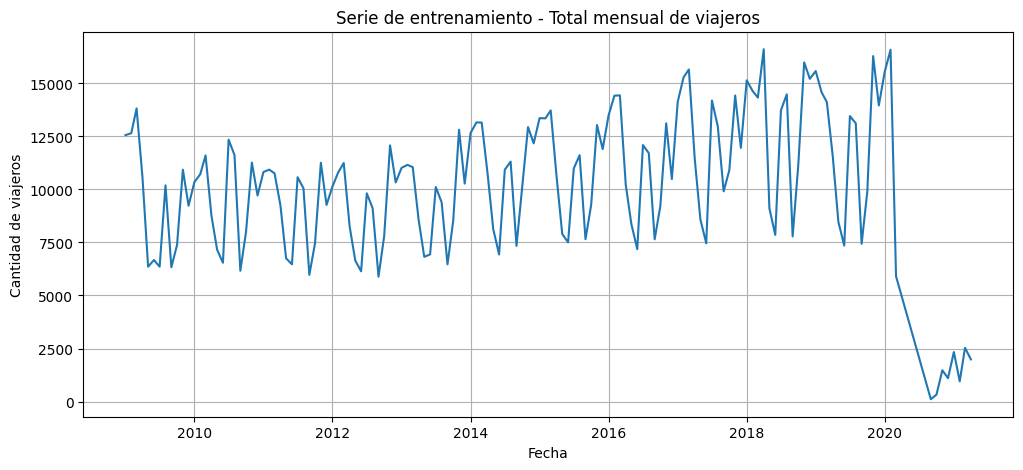

In [156]:
plt.figure(figsize=(12,5))

plt.plot(train)

plt.title("Serie de entrenamiento - Total mensual de viajeros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(True)

plt.show()

## Prueba de Dickey-Fuller

In [157]:
resultado_adf = adfuller(train)

print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.4f}")

print("\nValores críticos:")
for clave, valor in resultado_adf[4].items():
    print(f"{clave}: {valor:.4f}")

Estadístico ADF: -1.1441
p-valor: 0.6972

Valores críticos:
1%: -3.4825
5%: -2.8844
10%: -2.5790


## ACF y PACF

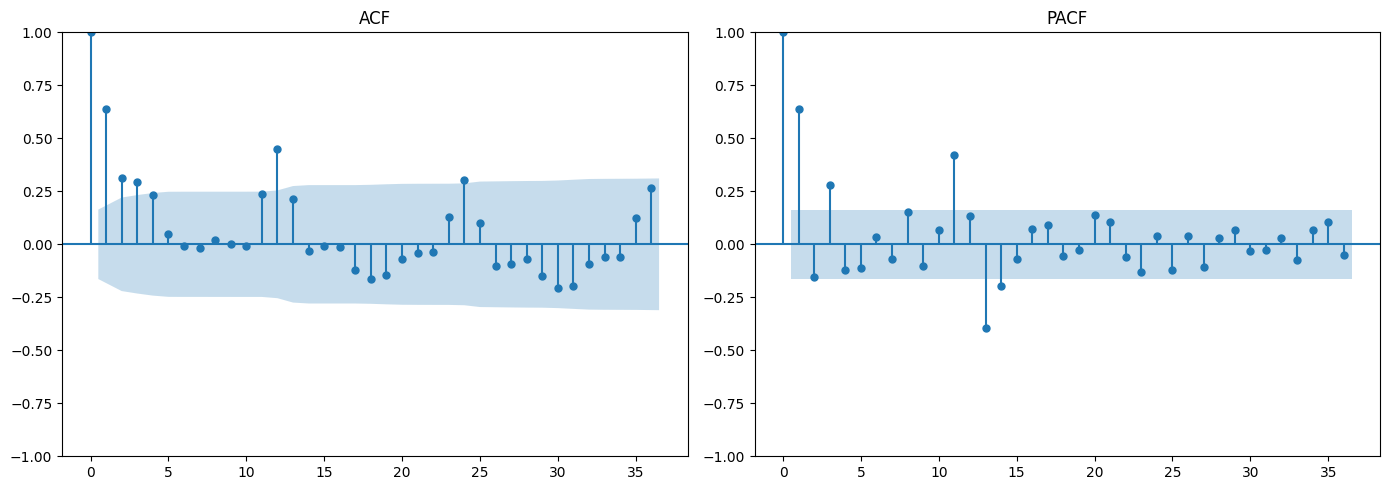

In [158]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

plot_acf(train, lags=36, ax=ax[0])
plot_pacf(train, lags=36, ax=ax[1], method="ywm")

ax[0].set_title("ACF")
ax[1].set_title("PACF")

plt.tight_layout()
plt.show()

## ARIMA

                               SARIMAX Results                                
Dep. Variable:                Viajero   No. Observations:                  143
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1322.172
Date:                Sun, 26 Jul 2026   AIC                           2650.345
Time:                        23:22:15   BIC                           2659.212
Sample:                             0   HQIC                          2653.948
                                - 143                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5764      0.107      5.395      0.000       0.367       0.786
ma.L1         -0.9122      0.083    -11.012      0.000      -1.075      -0.750
sigma2      7.124e+06   8.02e+05      8.888      0.0

c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


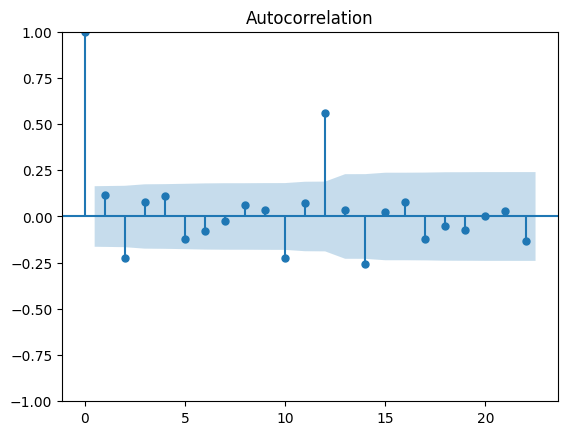

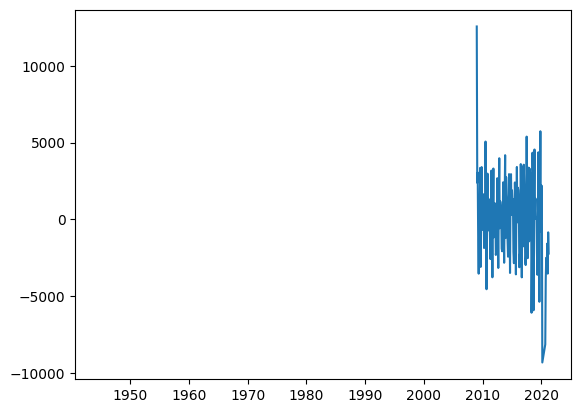

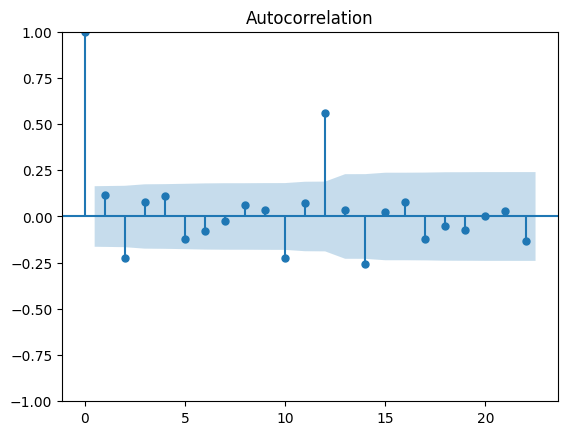

In [159]:
modelo1 = ARIMA(train, order=(1, 1, 1))
resultado1 = modelo1.fit()
print(resultado1.summary())
# Análisis de residuos
plt.plot(resultado1.resid)
plt.hist(resultado1.resid)
plot_acf(resultado1.resid)



c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

                               SARIMAX Results                                
Dep. Variable:                Viajero   No. Observations:                  143
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1318.446
Date:                Sun, 26 Jul 2026   AIC                           2644.892
Time:                        23:22:15   BIC                           2656.716
Sample:                             0   HQIC                          2649.697
                                - 143                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0466      0.216     -0.216      0.829      -0.469       0.376
ar.L2         -0.4064      0.058     -6.971      0.000      -0.521      -0.292
ma.L1         -0.0314      0.225     -0.140      0.8

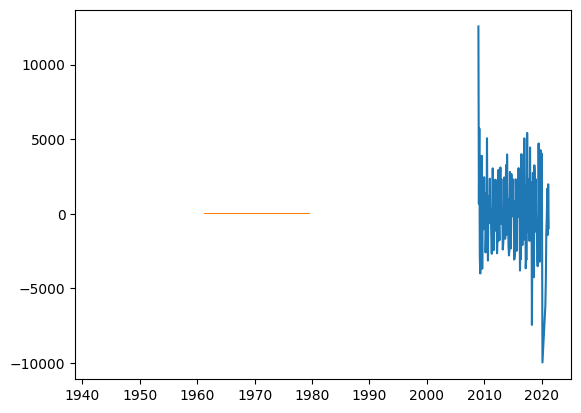

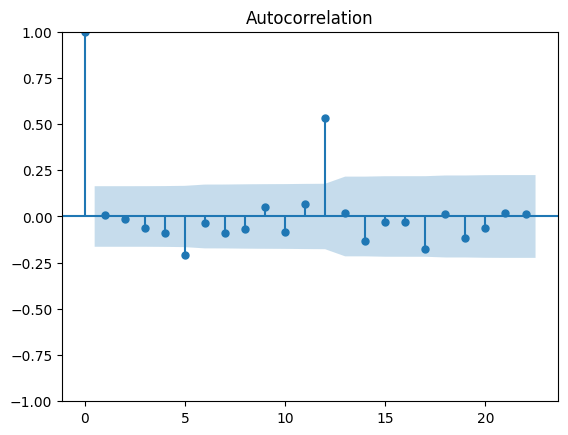

In [160]:
modelo2 = ARIMA(train, order=(2, 1, 1))
resultado2 = modelo2.fit()
print(resultado2.summary())
# Análisis de residuos
plt.plot(resultado2.resid)
plt.hist(resultado2.resid)
plot_acf(resultado2.resid)

# Predicción
pred_arima = resultado2.forecast(steps=len(test))
print(pred_arima)

aic_arima = resultado2.aic
bic_arima = resultado2.bic
mae_arima = mean_absolute_error(test, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
print(f"MAE ARIMA: {mae_arima:.4f}")
print(f"RMSE ARIMA: {rmse_arima:.4f}")


## Gráfica de predicción ARIMA

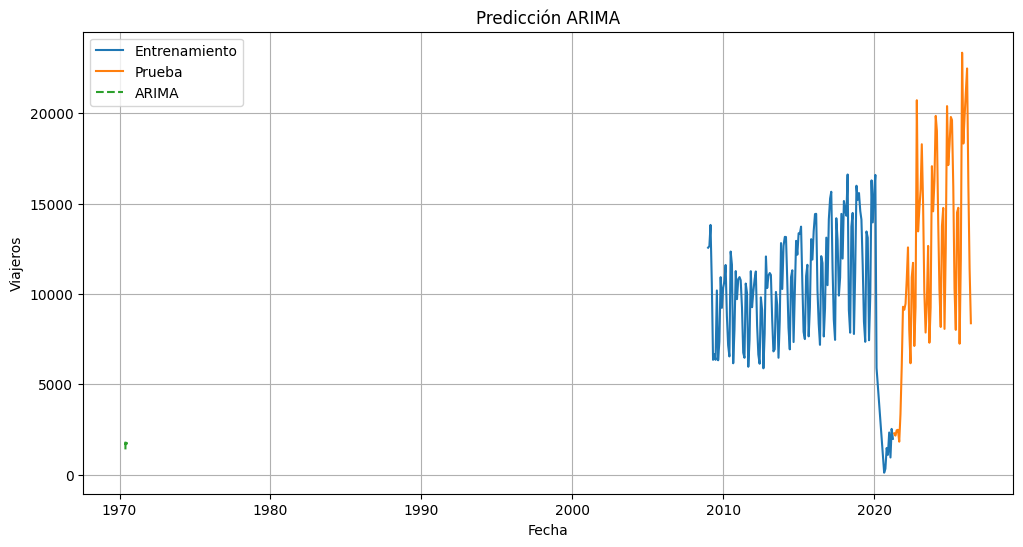

In [161]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Entrenamiento")

plt.plot(test.index, test.values, label="Prueba")
plt.plot(pred_arima.index, pred_arima.values,
         label="ARIMA",
         linestyle="--")

plt.title("Predicción ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.grid(True)

plt.show()

                               SARIMAX Results                                
Dep. Variable:                Viajero   No. Observations:                  143
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -1315.128
Date:                Sun, 26 Jul 2026   AIC                           2638.257
Time:                        23:22:16   BIC                           2650.080
Sample:                             0   HQIC                          2643.061
                                - 143                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1457      0.169      0.860      0.390      -0.186       0.477
ma.L1         -0.3046      0.170     -1.787      0.074      -0.639       0.030
ma.L2         -0.4569      0.088     -5.181      0.0

c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


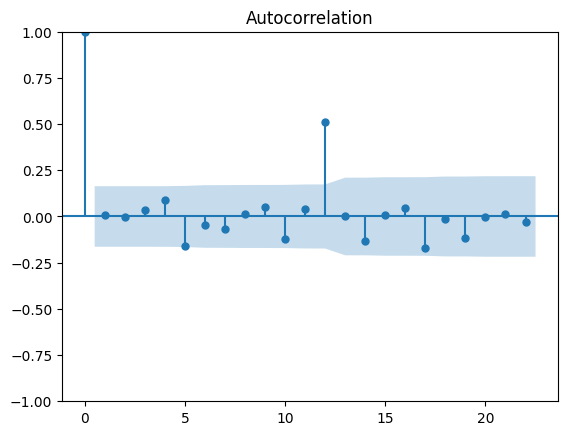

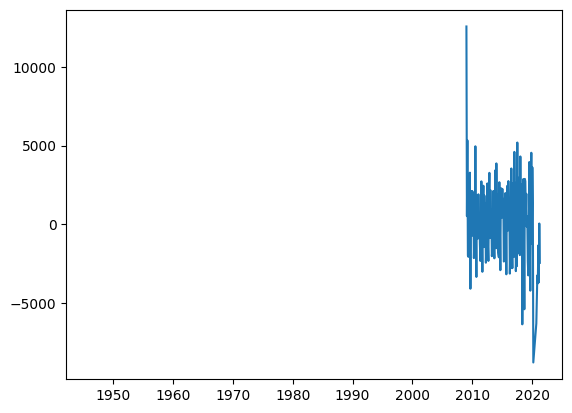

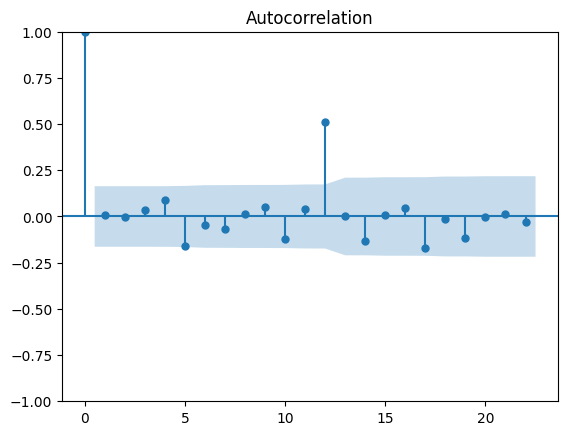

In [162]:
modelo3 = ARIMA(train, order=(1, 1, 2))
resultado3 = modelo3.fit()
print(resultado3.summary())
# Análisis de residuos
plt.plot(resultado3.resid)
plt.hist(resultado3.resid)
plot_acf(resultado3.resid)

Valores importantes: AIC: 3599.393. BIC: 3611.327

El mejor valor AIC y BIC es el modelo2, en cuanto al análisis de gráficas de residuos, están muy igualadas, por lo que el criterio de elección es el valor AIC y BIC.

## Holt-Winters

In [163]:
holtWinters1 = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)
resultado_hw1 = holtWinters1.fit()
print(resultado_hw1.summary())
pred_hw = resultado_hw1.forecast(steps=len(test))
print(pred_hw)

mae_hw = mean_absolute_error(test, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test, pred_hw))
print(f"MAE Holt-Winters: {mae_hw:.4f}")
print(f"RMSE Holt-Winters: {rmse_hw:.4f}")

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Viajero   No. Observations:                  143
Model:             ExponentialSmoothing   SSE                      368953527.734
Optimized:                         True   AIC                           2143.157
Trend:                         Additive   BIC                           2190.563
Seasonal:                      Additive   AICC                          2148.673
Seasonal Periods:                    12   Date:                 Sun, 26 Jul 2026
Box-Cox:                          False   Time:                         23:22:16
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6778639                alpha                 True
smoothing_trend          

c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Gráfica de Holt-Winters

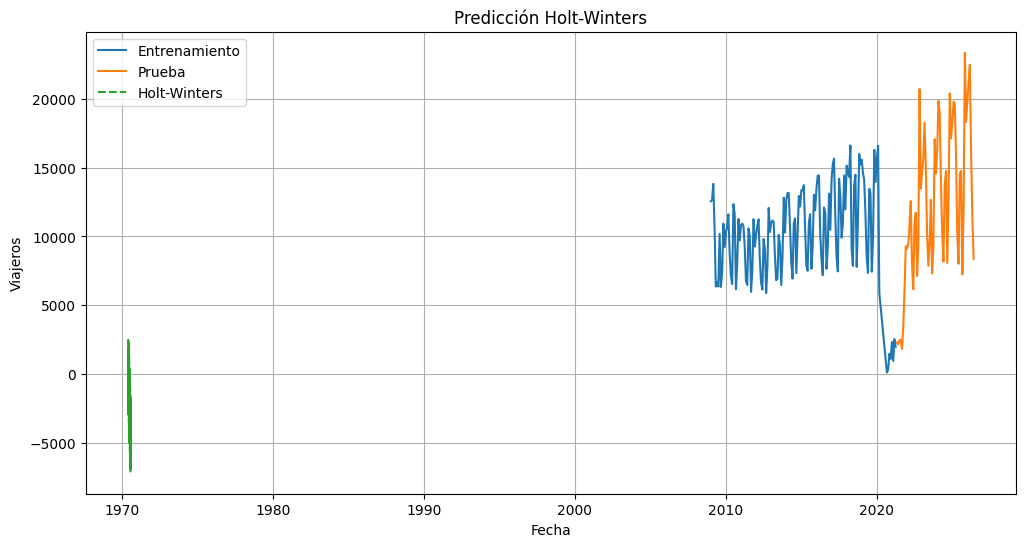

In [164]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Entrenamiento")

plt.plot(test.index, test.values, label="Prueba")

plt.plot(pred_hw.index, pred_hw.values,
         label="Holt-Winters",
         linestyle="--")

plt.title("Predicción Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.grid(True)

plt.show()

## Exponential Smoothing

In [165]:
exp_smoothing = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
)
resultado_exp_smoothing1 = exp_smoothing.fit()
print(resultado_exp_smoothing1.summary())
pred_exp_smoothing = resultado_exp_smoothing1.forecast(steps=len(test))
print(pred_exp_smoothing)

mae_exp_smoothing = mean_absolute_error(test, pred_exp_smoothing)
rmse_exp_smoothing = np.sqrt(mean_squared_error(test, pred_exp_smoothing))
print(f"MAE Exponential Smoothing: {mae_exp_smoothing:.4f}")
print(f"RMSE Exponential Smoothing: {rmse_exp_smoothing:.4f}")

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Viajero   No. Observations:                  143
Model:             ExponentialSmoothing   SSE                     1160358713.583
Optimized:                         True   AIC                           2283.009
Trend:                         Additive   BIC                           2294.860
Seasonal:                          None   AICC                          2283.626
Seasonal Periods:                  None   Date:                 Sun, 26 Jul 2026
Box-Cox:                          False   Time:                         23:22:16
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.6824282                alpha                 True
smoothing_trend             0.0000

c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Gráfica de predicción exponential smoothing

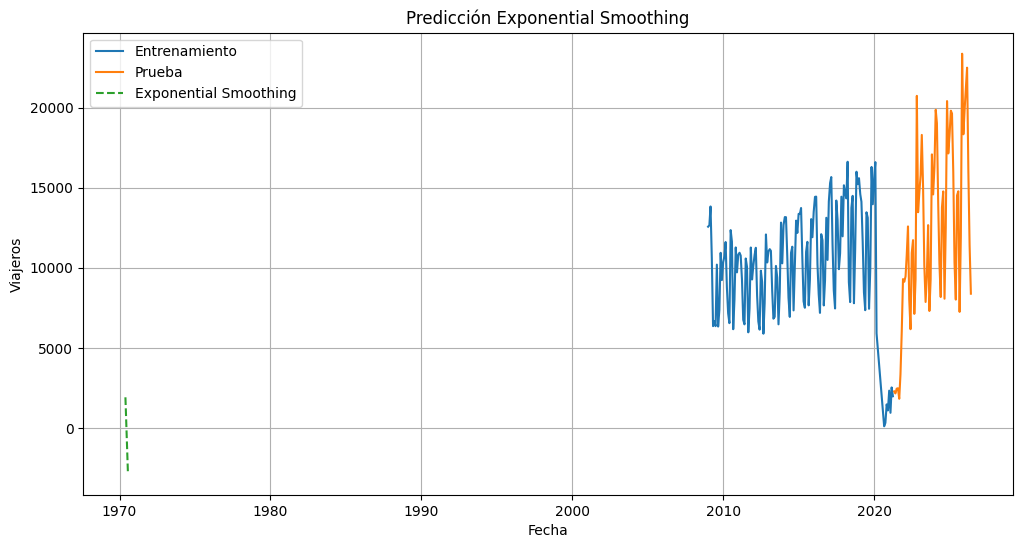

In [166]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Entrenamiento")

plt.plot(test.index, test.values, label="Prueba")

plt.plot(pred_exp_smoothing.index, pred_exp_smoothing.values,
         label="Exponential Smoothing",
         linestyle="--")

plt.title("Predicción Exponential Smoothing")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.grid(True)

plt.show()

## Seasonal Naive

In [167]:
ultimo_anio = train[-12:]

pred_snaive = np.tile(
    ultimo_anio.values,
    int(np.ceil(len(test) / 12))
)[:len(test)]

pred_snaive = pd.Series(
    pred_snaive,
    index=test.index
)
mae_snaive = mean_absolute_error(test, pred_snaive)
rmse_snaive = np.sqrt(mean_squared_error(test, pred_snaive))
print(f"MAE Seasonal Naive: {mae_snaive:.2f}")
print(f"RMSE Seasonal Naive: {rmse_snaive:.2f}")

MAE Seasonal Naive: 10675.31
RMSE Seasonal Naive: 11927.84


## Gráfica de Seasonal Naive

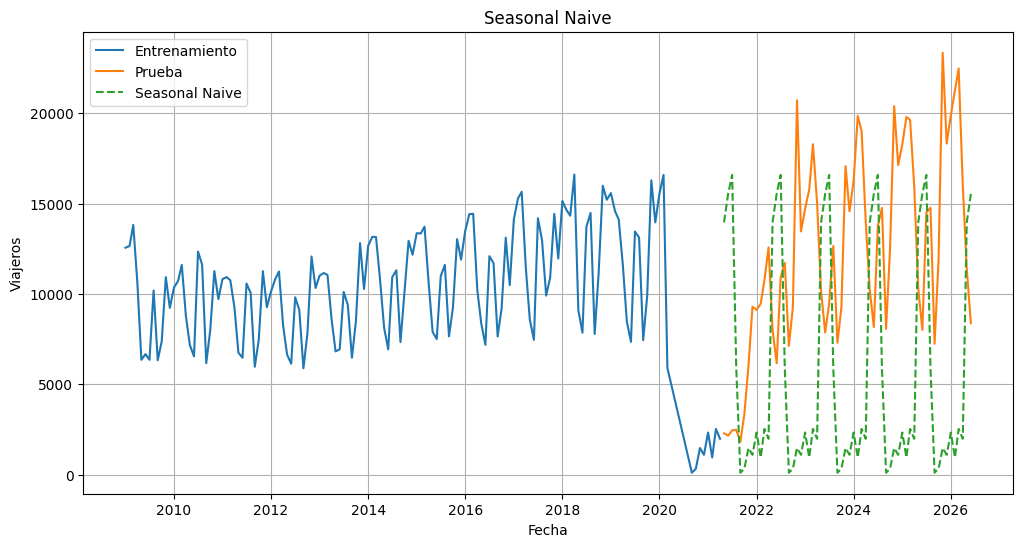

In [168]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Prueba")
plt.plot(pred_snaive, "--", label="Seasonal Naive")

plt.title("Seasonal Naive")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

## Prophet

In [169]:
train_prophet = train.reset_index()
train_prophet.columns = ["ds", "y"]
modelo_prophet = Prophet()
modelo_prophet.fit(train_prophet)
future = test.reset_index()
future.columns = ["ds", "y"]
future = future[["ds"]]
pred_prophet = modelo_prophet.predict(future)
pred_prophet[["ds", "yhat"]].head()
mae_prophet = mean_absolute_error(test, pred_prophet["yhat"])
rmse_prophet = np.sqrt(mean_squared_error(test, pred_prophet["yhat"]))
print(f"MAE Prophet: {mae_prophet:.4f}")
print(f"RMSE Prophet: {rmse_prophet:.4f}")

23:22:16 - cmdstanpy - INFO - Chain [1] start processing
23:22:16 - cmdstanpy - INFO - Chain [1] done processing


MAE Prophet: 10146.7974
RMSE Prophet: 11443.4985


## Gráfica de predicción de prophet

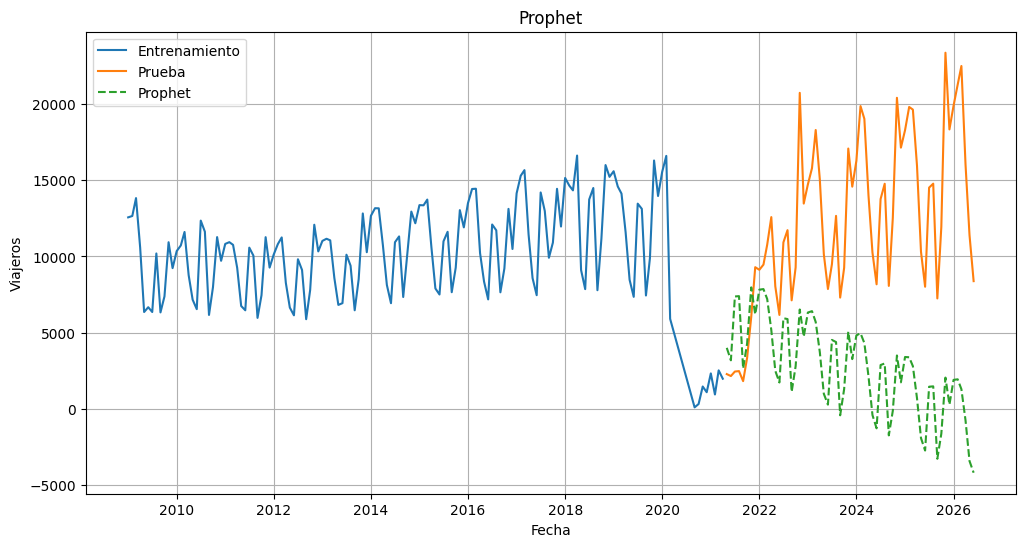

In [170]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Entrenamiento")
plt.plot(test.index, test.values, label="Prueba")

plt.plot(
    pred_prophet["ds"],
    pred_prophet["yhat"],
    "--",
    label="Prophet"
)

plt.title("Prophet")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

## Tabla comparativa de métricas

In [171]:
comparacion = pd.DataFrame({
    "Modelo": [
        "ARIMA",
        "Holt-Winters",
        "Exponential Smoothing",
        "Seasonal Naive",
        "Prophet"
    ],
    "MAE": [
        mae_arima,
        mae_hw,
        mae_exp_smoothing,
        mae_snaive,
        mae_prophet
    ],
    "RMSE": [
        rmse_arima,
        rmse_hw,
        rmse_exp_smoothing,
        rmse_snaive,
        rmse_prophet
    ],
    "AIC": [
        aic_arima,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],
    "BIC": [
        bic_arima,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]
})

comparacion.sort_values(by="RMSE", ascending=True)

,Modelo,MAE,RMSE,AIC,BIC
4,Prophet,10146.797374,11443.498530,NaN,NaN
3,Seasonal Naive,10675.306452,11927.840209,NaN,NaN
0,ARIMA,10646.486661,11983.522838,2644.892407,2656.715715
2,Exponential Smoothing,12842.558224,14369.580013,NaN,NaN
1,Holt-Winters,14270.667496,15982.939624,NaN,NaN
